# Prediksi Salary Karyawan — Project Machine Learning Kedua

Notebook ini bertujuan memprediksi **salary** seorang karyawan berdasarkan usia, gender, pendidikan, pengalaman kerja, dan jabatan. Ini adalah proyek machine learning kedua saya, dengan fokus melatih skill: menangani fitur teks berkardinalitas tinggi (`Job Title`, 174 kategori unik) lewat feature engineering, membedakan encoding ordinal vs nominal, serta evaluasi model regresi dengan MAE dan R².

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

## EDA

Dataset dimuat dan dicek strukturnya. Ditemukan 2 baris dengan seluruh kolom kosong (dropped) dan 1 baris dengan `Salary = 350` yang merupakan anomali/kemungkinan error input (jauh di luar skala wajar dibanding data lain). Setelah dibersihkan, dataset tersisa **372 baris**.

In [2]:
my_data = pd.read_csv("Salary Data.csv")
my_data.head()
my_data.describe()
# my_data.isnull().sum()
# my_data.shape
# my_data[my_data.isnull().any(axis=1)]
my_data = my_data.dropna()
my_data = my_data[my_data['Salary'] != 350]
print(my_data.head())
my_data.shape

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


(372, 6)

### Distribusi Target (Salary)


,count
Education Level,
Bachelor's,223
Master's,98
PhD,51


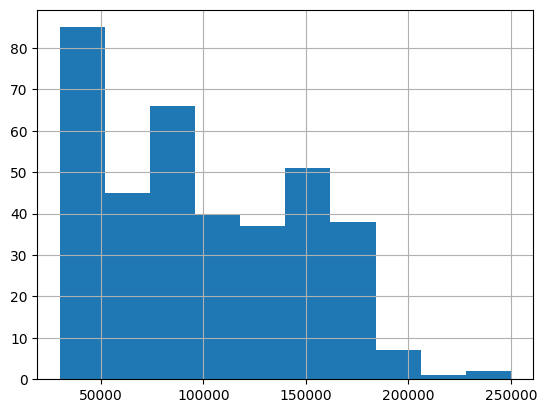

In [21]:
# my_data['Salary'].hist()
# my_data['salary_log'] = np.log(my_data['Salary'])
# my_data = my_data.drop(columns=['salary_log'])
my_data['Salary'].hist()
# my_data[my_data['salary_log'] < 10.5]
# my_data[my_data['Years of Experience'] < 3]['Salary'].value_counts()
# my_data['Salary'].value_counts()
my_data['Salary'].skew()
my_data['Job Title'].unique()[:30]
my_data['Education Level'].value_counts()

Histogram awal sempat terlihat skewed akibat outlier (`Salary = 350`) yang sudah dibuang di atas. Setelah pembersihan, Salary.skew() menghasilkan **~0.4** di bawah ambang skewed ringan (0.5), sehingga **tidak diperlukan transformasi log**. Di sini juga dilakukan pengecekan awal nilai unik 'Job Title' (untuk perencanaan feature engineering) dan distribusi 'Education Level'.

### Scatter Plot: Fitur Numerik vs Salary



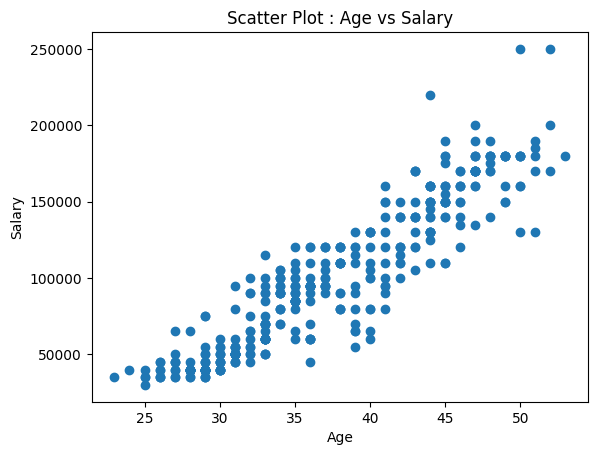

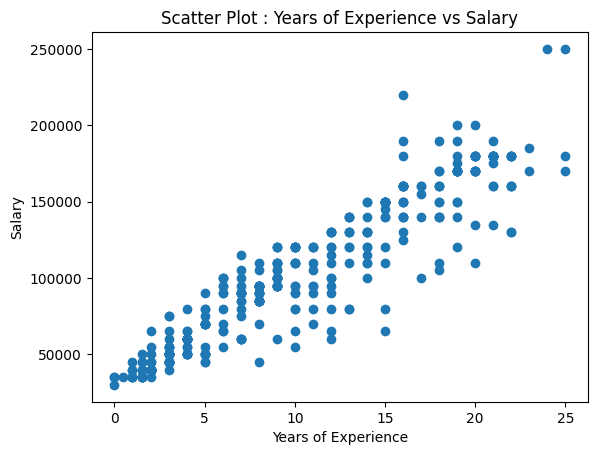

In [4]:
num = ['Age','Years of Experience']
for col in num:
  plt.figure()
  plt.scatter(my_data[col], my_data['Salary'])
  plt.title(f'Scatter Plot : {col} vs Salary')
  plt.xlabel(col)
  plt.ylabel('Salary')
  plt.show()

'Age' dan 'Years of Experience' masing-masing menunjukkan **korelasi positif** yang jelas terhadap 'Salary', terdapat kesimpulan bahwa semakin tinggi usia atau pengalaman, maka semakin tinggi salary. Hal tersebut juga berlaku di dunia bisnis.

### Feature Engineering: Job Seniority & Job Field



In [5]:
def extract_seniority(title):
    title = title.lower()
    if 'vp' in title or 'director' in title:
        return 'Director/VP'
    elif 'senior' in title or 'manager' in title:
        return 'Senior/Manager'
    elif 'junior' in title:
        return 'Junior'
    else:
        return 'Mid/Other'
my_data['Job_Seniority'] = my_data['Job Title'].apply(extract_seniority)

def extract_field(title):
    title = title.lower()
    if 'engineer' in title or 'developer' in title or 'architect' in title:
        return 'Engineering'
    elif 'analyst' in title or 'scientist' in title or 'data' in title:
        return 'Data/Analytics'
    elif 'sales' in title or 'account' in title or 'business development' in title:
        return 'Sales/Business Dev'
    elif 'marketing' in title or 'social media' in title or 'public relations' in title or 'copywriter' in title or 'content' in title or 'advertising' in title:
        return 'Marketing/Comms'
    elif 'hr' in title or 'human resources' in title or 'recruiter' in title or 'human capital' in title:
        return 'HR'
    elif 'financial' in title or 'finance' in title or 'accountant' in title:
        return 'Finance'
    elif 'operations' in title or 'supply chain' in title:
        return 'Operations'
    elif 'it ' in title or 'technical support' in title or 'it support' in title:
        return 'IT'
    elif 'design' in title or 'ux' in title:
        return 'Design'
    elif 'customer service' in title or 'customer success' in title or 'customer support' in title:
        return 'Customer Service'
    elif 'consultant' in title or 'strategy' in title:
        return 'Consulting'
    elif 'administrative' in title or 'office manager' in title or 'coordinator' in title or 'training' in title or 'entry clerk' in title:
        return 'Admin/Support'
    else:
        return 'Other'
my_data['Job_Field'] = my_data['Job Title'].apply(extract_field)

print(my_data.head())
print(my_data['Job_Field'].value_counts())
print(my_data['Job_Seniority'].value_counts(normalize='True'))

other_titles = my_data[my_data['Job_Field'] == 'Other']['Job Title'].unique()
print(other_titles)
print(len(other_titles))

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  salary_log   Job_Seniority           Job_Field  
0   90000.0   11.407565       Mid/Other         Engineering  
1   65000.0   11.082143       Mid/Other      Data/Analytics  
2  150000.0   11.918391  Senior/Manager               Other  
3   60000.0   11.002100       Mid/Other  Sales/Business Dev  
4  200000.0   12.206073     Director/VP               Other  
Job_Field
Data/Analytics        86
Marketing/Comms       61
Sales/Business Dev    43
Other                 39
Engineering           29
Operations            29
HR               

Kolom 'Job Title' asli punya **174 kategori unik** dari 372 baris, dengan jumlah sebanyak itu, terlalu detail untuk di-encode langsung (one-hot akan meledak jadi 174 kolom, ordinal tidak masuk akal karena title tidak punya urutan matematis). Sebagai solusi, dua fitur baru diekstrak dari teks title menggunakan pencocokan kata kunci:
- 'Job_Seniority': level jenjang karir (Junior, Mid/Other, Senior/Manager, Director/VP)
- 'Job_Field': bidang/departemen kerja (Engineering, Data/Analytics, Sales, dst.)

Kata kunci untuk 'Job_Field' diperluas secara iteratif setelah mengecek judul-judul yang jatuh ke kategori 'Other', porsi 'Other' berhasil diturunkan dari 43% menjadi ~10% setelah perbaikan. Sisa 'Other' yang ada memang berasal dari title generik tanpa info bidang eksplisit (contoh 'CEO', 'Director', 'Senior Manager').

Setelah kedua fitur ini dibuat, kolom 'Job Title' asli tidak lagi dipakai sebagai fitur model.

### Boxplot: Fitur Kategorikal (Gender, Education Level) vs Salary

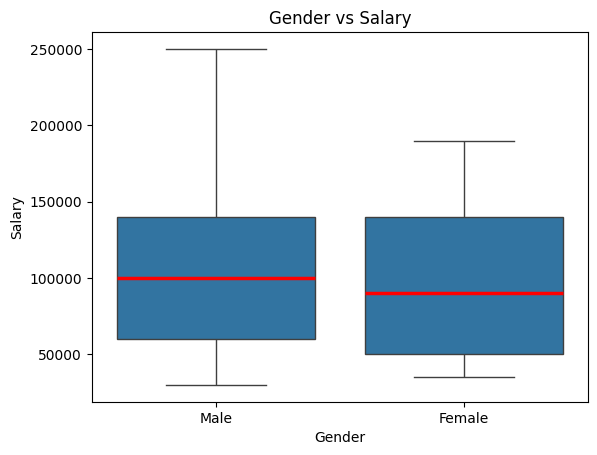

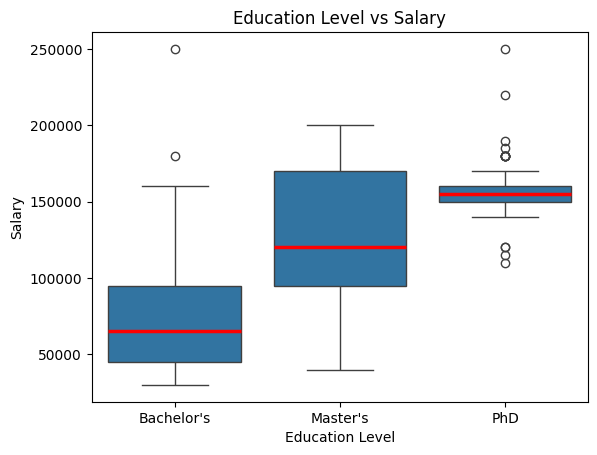

In [6]:
cat = ['Gender','Education Level']
for i in cat:
  sns.boxplot(x=i, y='Salary', data=my_data, medianprops=dict(color='red', linewidth=2.5))
  plt.title(f"{i} vs Salary")
  plt.show()

### Boxplot: Job Field vs Salary



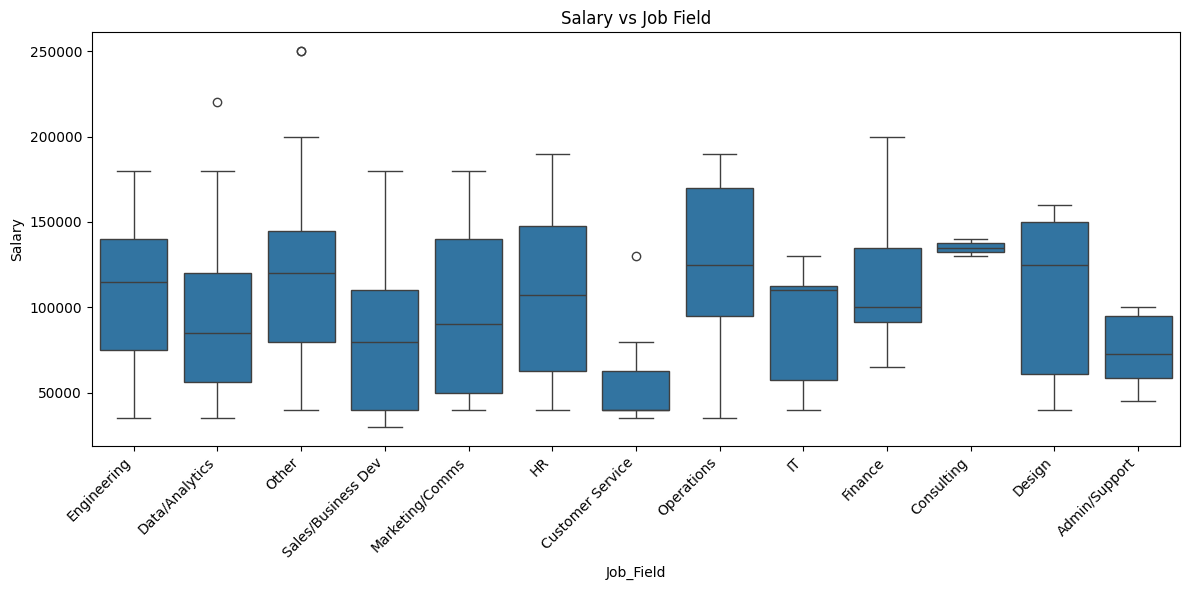

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Job_Field', y='Salary', data=my_data)
plt.xticks(rotation=45, ha='right')
plt.title('Salary vs Job Field')
plt.tight_layout()
plt.show()

Dengan 13 kategori pada 'Job_Field', label sumbu-X dirotasi 45° agar tetap terbaca. Beberapa kategori (misal 'Consulting') memiliki jumlah sampel yang sangat kecil, sehingga posisi kotaknya kurang bisa dipercaya sebagai representasi umum.

### Uji Statistik: Kruskal-Wallis untuk Job Field

Untuk memverifikasi perbedaan antar 13 kategori 'Job_Field' secara objektif (bukan cuma menduga dari visual boxplot), digunakan uji **Kruskal-Wallis** (perpanjangan konsep t-test untuk lebih dari 2 kelompok). Hasil: **p-value < 0.5**, bukti statistik kuat bahwa setidaknya ada perbedaan signifikan antar kategori 'Job_Field' terhadap 'Salary'.

In [8]:
groups = [my_data[my_data['Job_Field'] == cat]['Salary'] for cat in my_data['Job_Field'].unique()]
stats.kruskal(*groups)

KruskalResult(statistic=np.float64(41.040781306160554), pvalue=np.float64(4.823918860891812e-05))

### Boxplot: Job Seniority vs Salary

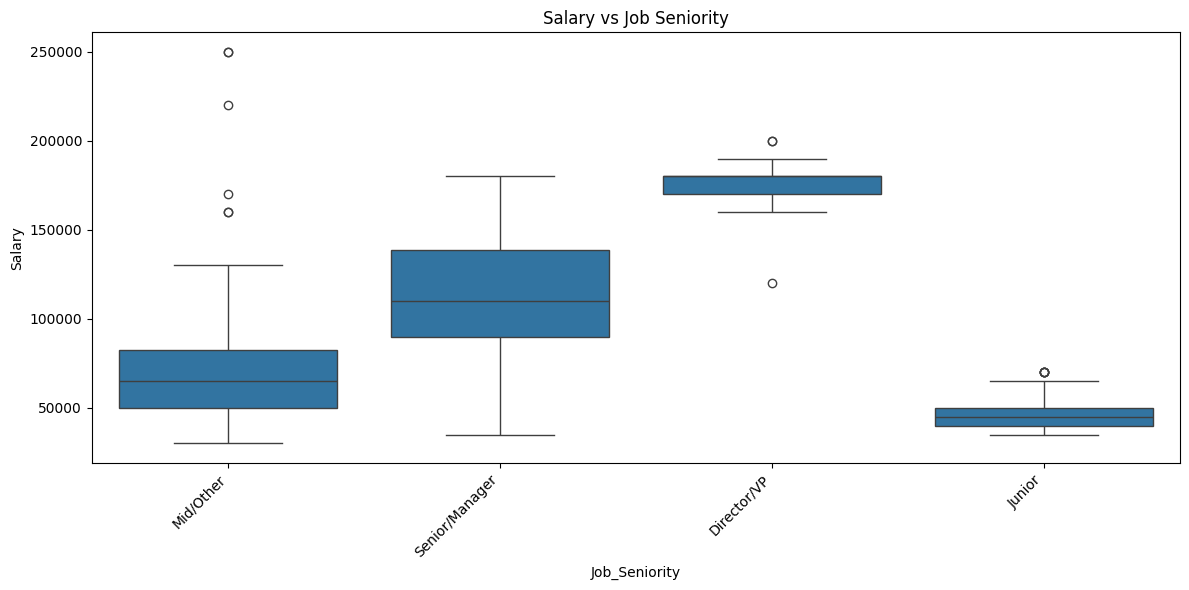

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Job_Seniority', y='Salary', data=my_data)
plt.xticks(rotation=45, ha='right')
plt.title('Salary vs Job Seniority')
plt.tight_layout()
plt.show()

### Cek Distribusi Kategori



In [10]:
print(my_data['Education Level'].value_counts())
print(my_data['Job_Seniority'].value_counts())
my_data['Gender'].value_counts(normalize='True')

Education Level
Bachelor's    223
Master's       98
PhD            51
Name: count, dtype: int64
Job_Seniority
Senior/Manager    198
Junior             71
Mid/Other          59
Director/VP        44
Name: count, dtype: int64


,proportion
Gender,
Male,0.518817
Female,0.481183


Pengecekan proporsi tiap kategori: 'Education Level' didominasi Bachelor's, 'Job_Seniority' didominasi Senior/Manager, dan 'Gender' terbagi cukup seimbang (Male 51.9% / Female 48.1%).

## Feature Engineering & Preprocessing

### Encoding Ordinal Manual (Education Level & Job Seniority)

'Education Level' dan 'Job_Seniority' sama-sama punya **urutan logis** (Bachelor's < Master's < PhD; Junior < Mid/Other < Senior/Manager < Director/VP), sehingga di-encode secara **manual** (bukan 'OrdinalEncoder' otomatis, karena urutan alfabetis defaultnya tidak sesuai urutan jenjang yang sebenarnya). Karena aturan mapping ini ditentukan sendiri (bukan dipelajari dari data), proses ini aman dilakukan sebelum split train/valid.

In [11]:
edlevelmap = {"Bachelor's":1, "Master's":2, "PhD":3}
jobsenmap = {'Senior/Manager':3, 'Junior':1, 'Mid/Other':2, 'Director/VP':4}

my_data['Education_Level_Encode'] = my_data['Education Level'].map(edlevelmap)
my_data['Job_Seniority_Encode'] = my_data['Job_Seniority'].map(jobsenmap)

print(my_data.head())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  salary_log   Job_Seniority           Job_Field  \
0   90000.0   11.407565       Mid/Other         Engineering   
1   65000.0   11.082143       Mid/Other      Data/Analytics   
2  150000.0   11.918391  Senior/Manager               Other   
3   60000.0   11.002100       Mid/Other  Sales/Business Dev   
4  200000.0   12.206073     Director/VP               Other   

   Education_Level_Encode  Job_Seniority_Encode  
0                       1                     2  
1                       2                     2  
2                   

### Pemilihan Fitur dan Target

Fitur final yang dipakai: 'Age', 'Gender', 'Years of Experience', 'Job_Field', 'Education_Level_Encode', 'Job_Seniority_Encode'.

Target: 'Salary'.

In [12]:
my_features = ['Age','Gender','Years of Experience','Job_Field','Education_Level_Encode','Job_Seniority_Encode']
x = my_data[my_features]
y = my_data.Salary

### Split Data & One-Hot Encoding (Gender, Job_Field)

Data displit terlebih dahulu sebelum encoding 'Gender' dan 'Job_Field' (keduanya tidak memiliki urutan) menggunakan 'OneHotEncoder', di-*fit* hanya pada 'x_train', lalu di-*transform* ke 'x_valid', untuk menghindari data leakage. Parameter handle_unknown='ignore' mengantisipasi kategori 'Job_Field' yang mungkin hanya muncul di salah satu sisi split (mengingat ada 13 kategori dari data yang relatif kecil).

In [13]:
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=42)

cat_cols = ['Gender','Job_Field']
encoder = OneHotEncoder(sparse_output = False, handle_unknown='ignore')

x_train_ohe = encoder.fit_transform(x_train[cat_cols])
x_valid_ohe = encoder.transform(x_valid[cat_cols])

x_train_ohe = pd.DataFrame(x_train_ohe, columns=encoder.get_feature_names_out(cat_cols), index=x_train.index)
x_valid_ohe = pd.DataFrame(x_valid_ohe, columns=encoder.get_feature_names_out(cat_cols), index=x_valid.index)

x_train_final = pd.concat([x_train.drop(columns=cat_cols), x_train_ohe], axis=1)
x_valid_final = pd.concat([x_valid.drop(columns=cat_cols), x_valid_ohe], axis=1)

### Verifikasi Tidak Ada Missing Value

Pengecekan akhir sebelum training. Memastikan proses cleaning, feature engineering, dan encoding di atas tidak meninggalkan nilai kosong.

In [14]:
x_train_final.isnull().sum()
x_valid_final.isnull().sum()

,0
Age,0
Years of Experience,0
Education_Level_Encode,0
Job_Seniority_Encode,0
Gender_Female,0
Gender_Male,0
Job_Field_Admin/Support,0
Job_Field_Consulting,0
Job_Field_Customer Service,0
Job_Field_Data/Analytics,0


## Training Model (RandomForestRegressor)

In [15]:
model = RandomForestRegressor(random_state = 0)

model.fit(x_train_final, y_train)

RandomForestRegressor(random_state=0)

### Evaluasi Model: MAE & R²

Hasil evaluasi pada 'x_valid_final': **MAE ≈ 8501** (setara **8.43%** relatif terhadap rata-rata salary) dan **R² ≈ 0.89** — model berhasil menjelaskan sekitar 89% variasi salary dari fitur yang digunakan. Ini merupakan hasil yang kuat, meski perlu diinterpretasi dengan hati-hati mengingat ukuran dataset yang kecil (372 baris).

In [16]:
pred = model.predict(x_valid_final)
mae = mean_absolute_error(y_valid, pred)

print(mae)

mae_percentage = (mae / y_valid.mean()) * 100
print(f"MAE relatif: {mae_percentage:.2f}%")

r2 = r2_score(y_valid, pred)
print(f"Nilai R2 : {r2}")

8501.139682539682
MAE relatif: 8.43%
Nilai R2 : 0.8915730343500745


### Feature Importance

'Age' muncul sebagai fitur paling dominan, diikuti 'Years of Experience', 'Job_Seniority_Encode', dan 'Education_Level_Encode'. Seluruh kategori 'Job_Field' dan 'Gender' hasil one-hot masing-masing berkontribusi sangat kecil (di bawah 0.01) yang konsisten dengan hasil boxplot yang menunjukkan overlap cukup besar antar kategori untuk fitur-fitur tersebut.

In [17]:
importances = pd.Series(model.feature_importances_, index=x_train_final.columns)
importances = importances.sort_values(ascending=False)
print(importances)

Age                             0.605814
Years of Experience             0.273079
Job_Seniority_Encode            0.067361
Education_Level_Encode          0.028339
Job_Field_Admin/Support         0.003299
Job_Field_Other                 0.003106
Job_Field_HR                    0.003096
Job_Field_Sales/Business Dev    0.002667
Job_Field_Data/Analytics        0.002247
Gender_Female                   0.002071
Job_Field_Marketing/Comms       0.001852
Gender_Male                     0.001481
Job_Field_Operations            0.001422
Job_Field_Customer Service      0.001083
Job_Field_Engineering           0.001073
Job_Field_Finance               0.000914
Job_Field_Consulting            0.000483
Job_Field_Design                0.000462
Job_Field_IT                    0.000150
dtype: float64


### Visualisasi Feature Importance

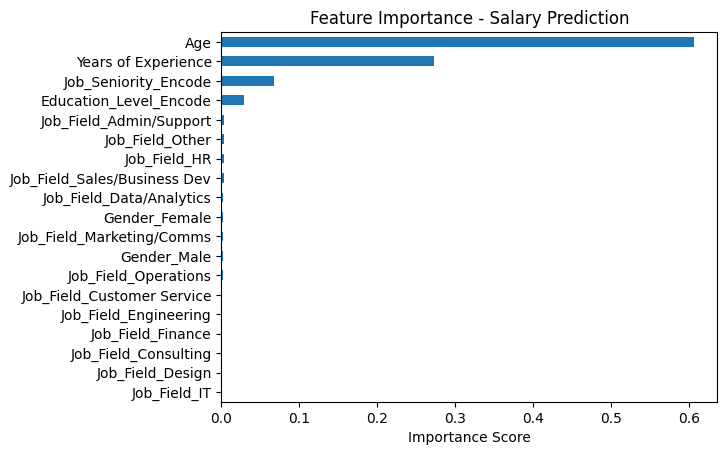

In [18]:
importances.plot(kind='barh')
plt.title('Feature Importance - Salary Prediction')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

### Investigasi: Korelasi Age vs Years of Experience

Karena 'Age' mendominasi feature importance jauh di atas fitur lain, dicek potensi redundansi dengan 'Years of Experience'. Hasilnya: **korelasi 0.979**, mengonfirmasi usia dan pengalaman kerja bergerak sangat beriringan di dataset ini.

In [19]:
my_data[['Age', 'Years of Experience']].corr()

,Age,Years of Experience
Age,1.000000,0.979056
Years of Experience,0.979056,1.000000


### Eksperimen: Model Tanpa Fitur Age

Untuk menguji apakah 'Age' sekadar representasi 'Years of Experience' (redundant) atau membawa informasi unik, model dilatih ulang tanpa 'Age'. Hasilnya: MAE justru **naik** menjadi 8992 (8.92% relatif), menunjukkan 'Age' membawa informasi yang tidak sepenuhnya tertangkap oleh 'Years of Experience'. Menariknya, **R² sedikit naik** menjadi 0.893 — hal ini masuk akal karena MAE dan R² mengukur error dengan cara berbeda (R² menghukum error besar secara kuadratik), sehingga keduanya bisa berlawanan arah pada selisih yang kecil. **Catatan keterbatasan:** karena dataset ini kecil (~372 baris, validasi hanya ~75 baris), selisih hasil sekecil ini berpotensi dipengaruhi kebetulan pembagian data (random split), bukan sinyal yang pasti kuat. Validasi lebih lanjut (mis. cross-validation) akan memerlukan restrukturisasi pipeline preprocessing di luar cakupan project ini.

In [20]:
x_train_no_age = x_train_final.drop(columns=['Age'])
x_valid_no_age = x_valid_final.drop(columns=['Age'])

model_no_age = RandomForestRegressor(random_state=0)
model_no_age.fit(x_train_no_age, y_train)

preds_no_age = model_no_age.predict(x_valid_no_age)

mae_no_age = mean_absolute_error(y_valid, preds_no_age)
print(mae_no_age)
mae_no_age_percentage = (mae_no_age/y_valid.mean())*100
print(f"persentase MAE: {mae_no_age_percentage:.2f}%")
r2_no_age = r2_score(y_valid, preds_no_age)
print(f"R2: {r2_no_age}")

8992.46455026455
persentase MAE: 8.92%
R2: 0.8930445767016693


## Kesimpulan Akhir

Model 'RandomForestRegressor' berhasil memprediksi salary dengan performa yang kuat: **MAE relatif 8.43%** dan **R² 0.89**. Fitur paling berpengaruh adalah 'Age' dan 'Years of Experience', meski keduanya berkorelasi sangat tinggi (0.979). Eksperimen menghapus 'Age' menunjukkan performa MAE justru memburuk, mengindikasikan 'Age' membawa informasi yang tidak sepenuhnya tertangkap oleh 'Years of Experience' semata.

Fitur kategorikal ('Job_Field', 'Gender') berkontribusi jauh lebih kecil dibanding fitur numerik, meski uji Kruskal-Wallis mengonfirmasi 'Job_Field' tetap punya hubungan signifikan secara statistik dengan salary.

**Keterbatasan utama:** ukuran dataset yang kecil membuat beberapa temuan khususnya perbandingan importance 'Age' vs 'Years of Experience', berpotensi sensitif terhadap kebetulan pembagian data. Validasi lebih lanjut lewat cross-validation atau dataset yang lebih besar akan memperkuat kesimpulan ini.